# **6주차 강화학습 실습**

안녕하세요.

Tobig's 24기 서민정, 정서윤입니다.

본 실습은 3x4 그리드 월드(GridWorld) 환경에서 에이전트가 함정을 피하고 목표 지점에 도달하는 최적의 경로를 학습하는 과정을 다룹니다.

환경의 완벽한 정보를 안다고 가정하는 동적 계획법(DP)부터, 경험을 통해 학습하는 몬테카를로(MC)와 시간차 학습(TD) 알고리즘까지 순차적으로 구현해봅니다. 이를 통해 각 강화학습 알고리즘의 작동 원리를 깊이 이해하고, 실질적인 차이점을 비교 분석해보겠습니다.

# **3x4 그리드 월드**

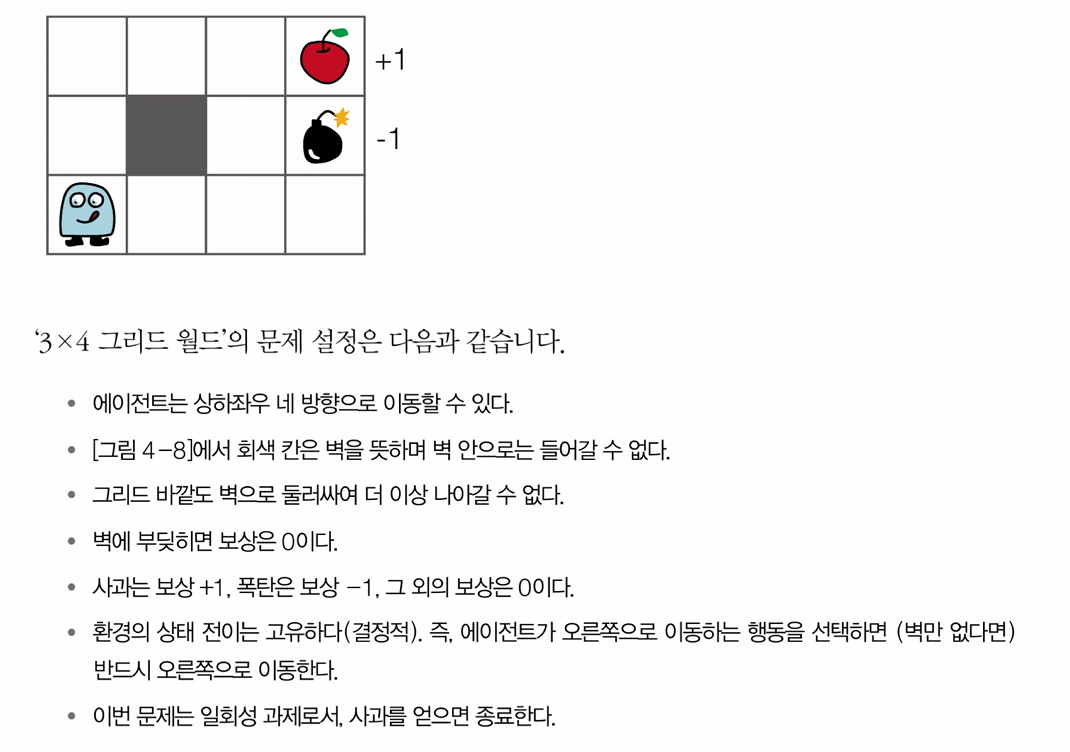

# **동적 프로그래밍(Dynamic Programming)**

동적 계획법은 환경의 전이 확률과 보상 함수를 모두 알고 있다는 가정 하에 동작합니다. 가치 반복(Value Iteration)은 벨만 최적 방정식을 업데이트 규칙으로 사용하여, 상태 가치 함수가 수렴할 때까지 반복 계산하여 최적 가치 함수와 최적 정책을 찾습니다.

**SETUP**

In [ ]:
# install gridworld from pip
!pip install dezerogym

**1. 환경 초기화 및 무작위 가치 함수 시각화**

In [ ]:
import numpy as np
from dezerogym.gridworld import GridWorld

env = GridWorld()
V = {}

for state in env.states():
    V[state] = np.random.randn()
env.render_v(V)

**2. 정책 평가 (Policy Evaluation)**

In [ ]:
from collections import defaultdict
from dezerogym.gridworld import GridWorld


def eval_onestep(pi, V, env, gamma=0.9):
    for state in env.states():
        if state == env.goal_state:
            V[state] = 0
            continue

        action_probs = pi[state]
        new_V = 0
        for action, action_prob in action_probs.items():
            next_state = env.next_state(state, action)
            r = env.reward(state, action, next_state)
            new_V += action_prob * (r + gamma * V[next_state])
        V[state] = new_V
    return V


def policy_eval(pi, V, env, gamma, threshold=0.001):
    while True:
        old_V = V.copy()
        V = eval_onestep(pi, V, env, gamma)

        delta = 0
        for state in V.keys():
            t = abs(V[state] - old_V[state])
            if delta < t:
                delta = t

        if delta < threshold:
            break
    return V


env = GridWorld()
gamma = 0.9

pi = defaultdict(lambda: {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25})
V = defaultdict(lambda: 0)

V = policy_eval(pi, V, env, gamma)
env.render_v(V, pi)

**3. 정책 반복 (Policy Iteration)**

In [ ]:
def argmax(d):
    """d (dict)"""
    max_value = max(d.values())
    max_key = -1
    for key, value in d.items():
        if value == max_value:
            max_key = key
    return max_key


def greedy_policy(V, env, gamma):
    pi = {}

    for state in env.states():
        action_values = {}

        for action in env.actions():
            next_state = env.next_state(state, action)
            r = env.reward(state, action, next_state)
            value = r + gamma * V[next_state]
            action_values[action] = value

        max_action = argmax(action_values)
        action_probs = {0: 0, 1: 0, 2: 0, 3: 0}
        action_probs[max_action] = 1.0
        pi[state] = action_probs
    return pi


def policy_iter(env, gamma, threshold=0.001, is_render=True):
    pi = defaultdict(lambda: {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25})
    V = defaultdict(lambda: 0)

    while True:
        V = policy_eval(pi, V, env, gamma, threshold)
        new_pi = greedy_policy(V, env, gamma)

        if is_render:
            env.render_v(V, pi)

        if new_pi == pi:
            break
        pi = new_pi

    return pi


env = GridWorld()
gamma = 0.9
pi = policy_iter(env, gamma)


**4. 가치 반복 (Value Iteration)**

In [ ]:
def value_iter_onestep(V, env, gamma):
    for state in env.states():
        if state == env.goal_state:
            V[state] = 0
            continue

        action_values = []
        for action in env.actions():
            next_state = env.next_state(state, action)
            r = env.reward(state, action, next_state)
            value = r + gamma * V[next_state]
            action_values.append(value)

        V[state] = max(action_values)
    return V


def value_iter(V, env, gamma, threshold=0.001, is_render=True):
    while True:
        if is_render:
            env.render_v(V)

        old_V = V.copy()
        V = value_iter_onestep(V, env, gamma)

        delta = 0
        for state in V.keys():
            t = abs(V[state] - old_V[state])
            if delta < t:
                delta = t

        if delta < threshold:
            break
    return V


V = defaultdict(lambda: 0)
env = GridWorld()
gamma = 0.9

V = value_iter(V, env, gamma)

pi = greedy_policy(V, env, gamma)
env.render_v(V, pi)

# **몬테카를로법(Monte Carlo Method)**

몬테카를로 방법은 환경의 모델을 모를 때, 에이전트가 직접 환경과 상호작용하며 얻은 에피소드(경험)를 바탕으로 학습합니다. 에피소드가 끝날 때까지 기다렸다가 실제 얻은 반환값을 사용하여 Q-함수를 업데이트합니다. 여기서 구현하는 비활성 정책(Off-policy) MC는 탐험을 위한 행동 정책(Behavior Policy)과 최적화하려는 목표 정책(Target Policy)을 분리하고 중요도 샘플링을 적용합니다.

**SETUP**

In [ ]:
from collections import defaultdict
import numpy as np
from dezerogym.gridworld import GridWorld

**1. 무작위 에이전트를 이용한 MC 정책 평가**

In [ ]:
class RandomAgent:
    def __init__(self):
        self.gamma = 0.9
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.V = defaultdict(lambda: 0)
        self.cnts = defaultdict(lambda: 0)
        self.memory = []

    def get_action(self, state):
        action_probs = self.pi[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def add(self, state, action, reward):
        data = (state, action, reward)
        self.memory.append(data)

    def reset(self):
        self.memory.clear()

    def eval(self):
        G = 0
        for data in reversed(self.memory):  # 역방향으로(reserved) 따라가기
            state, action, reward = data
            G = self.gamma * G + reward
            self.cnts[state] += 1
            self.V[state] += (G - self.V[state]) / self.cnts[state]


env = GridWorld()
agent = RandomAgent()

episodes = 1000
for episode in range(episodes):  # 에피소드 1000번 수행
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)             # 행동 선택
        next_state, reward, done = env.step(action)  # 행동 수행

        agent.add(state, action, reward)  # (상태, 행동, 보상) 저장
        if done:   # 목표에 도달 시
            agent.eval()  # 몬테카를로법으로 가치 함수 갱신
            break         # 다음 에피소드 시작

        state = next_state

# 모든 에피소드 종료

# 가치 함수 시각화
env.render_v(agent.V)

**[공통 유틸리티] 엡실론-탐욕(epsilon-greedy) 확률 계산 함수**

In [ ]:
def greedy_probs(Q, state, epsilon=0, action_size=4):
    qs = [Q[(state, action)] for action in range(action_size)]
    max_action = np.argmax(qs)

    base_prob = epsilon / action_size
    action_probs = {action: base_prob for action in range(action_size)}  #{0: ε/4, 1: ε/4, 2: ε/4, 3: ε/4}
    action_probs[max_action] += (1 - epsilon)
    return action_probs

**2. 활성 정책 MC 제어 (On-Policy MC Control)**

In [ ]:
class McAgent:
    def __init__(self):
        self.gamma = 0.9
        self.epsilon = 0.1  # (첫 번째 개선) ε-탐욕 정책의 ε
        self.alpha = 0.1    # (두 번째 개선) Q 함수 갱신 시의 고정값 α
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)
        # self.cnts = defaultdict(lambda: 0)
        self.memory = []

    def get_action(self, state):
        action_probs = self.pi[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def add(self, state, action, reward):
        data = (state, action, reward)
        self.memory.append(data)

    def reset(self):
        self.memory.clear()

    def update(self):
        G = 0
        for data in reversed(self.memory):
            state, action, reward = data
            G = self.gamma * G + reward
            key = (state, action)
            # self.cnts[key] += 1
            # self.Q[key] += (G - self.Q[key]) / self.cnts[key]
            self.Q[key] += (G - self.Q[key]) * self.alpha
            self.pi[state] = greedy_probs(self.Q, state, self.epsilon)


env = GridWorld()
agent = McAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.add(state, action, reward)
        if done:
            agent.update()
            break

        state = next_state

env.render_q(agent.Q)

**3. 비활성 정책 MC 제어 (Off-Policy MC Control)**

In [ ]:
class McOffPolicyAgent:
    def __init__(self):
        self.gamma = 0.9
        self.epsilon = 0.1
        self.alpha = 0.2
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.b = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)
        self.memory = []

    def get_action(self, state):
        action_probs = self.b[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def add(self, state, action, reward):
        data = (state, action, reward)
        self.memory.append(data)

    def reset(self):
        self.memory.clear()

    def update(self):
        G = 0
        rho = 1

        for data in reversed(self.memory):
            state, action, reward = data
            key = (state, action)

            G = self.gamma * rho * G + reward
            self.Q[key] += (G - self.Q[key]) * self.alpha
            rho *= self.pi[state][action] / self.b[state][action]

            self.pi[state] = greedy_probs(self.Q, state, epsilon=0)
            self.b[state] = greedy_probs(self.Q, state, self.epsilon)


env = GridWorld()
agent = McOffPolicyAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.add(state, action, reward)
        if done:
            agent.update()
            break

        state = next_state

env.render_q(agent.Q)

# **TD법(Temporal Difference Methods)**

시간차(TD) 학습은 MC와 마찬가지로 모델 없이 학습하지만, 에피소드가 끝날 때까지 기다리지 않고 매 타임스텝마다 학습합니다. Q-Learning은 TD의 대표적인 비활성 정책 제어 알고리즘으로, 다음 상태에서 가능한 가장 큰 Q-값을 다음 타겟으로 사용하여 현재 상태의 Q-값을 실시간으로 업데이트합니다.

**[공통 유틸리티 함수]**

In [ ]:
# utility functions (common functions)
def argmax(xs):
    idxes = [i for i, x in enumerate(xs) if x == max(xs)]
    if len(idxes) == 1:
        return idxes[0]
    elif len(idxes) == 0:
        return np.random.choice(len(xs))
    selected = np.random.choice(idxes)
    return selected

def greedy_probs(Q, state, epsilon=0, action_size=4):
    qs = [Q[(state, action)] for action in range(action_size)]
    max_action = argmax(qs)  # OR np.argmax(qs)
    base_prob = epsilon / action_size
    action_probs = {action: base_prob for action in range(action_size)}  #{0: ε/4, 1: ε/4, 2: ε/4, 3: ε/4}
    action_probs[max_action] += (1 - epsilon)
    return action_probs

**1. TD 정책 평가 (TD Evaluation)**

In [ ]:
from collections import defaultdict
import numpy as np
from dezerogym.gridworld import GridWorld


class TdAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.01
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.V = defaultdict(lambda: 0)

    def get_action(self, state):
        action_probs = self.pi[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def eval(self, state, reward, next_state, done):
        next_V = 0 if done else self.V[next_state]
        target = reward + self.gamma * next_V
        self.V[state] += (target - self.V[state]) * self.alpha


env = GridWorld()
agent = TdAgent()

episodes = 1000
for episode in range(episodes):
    state = env.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.eval(state, reward, next_state, done)
        if done:
            break
        state = next_state

env.render_v(agent.V)

**2. SARSA (활성 정책 TD 제어, On-Policy TD Control)**

In [ ]:
from collections import deque


class SarsaAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)
        self.memory = deque(maxlen=2)

    def get_action(self, state):
        action_probs = self.pi[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def reset(self):
        self.memory.clear()

    def update(self, state, action, reward, done):
        self.memory.append((state, action, reward, done))
        if len(self.memory) < 2:
            return

        state, action, reward, done = self.memory[0]
        next_state, next_action, _, _ = self.memory[1]
        next_q = 0 if done else self.Q[next_state, next_action]

        target = reward + self.gamma * next_q
        self.Q[state, action] += (target - self.Q[state, action]) * self.alpha
        self.pi[state] = greedy_probs(self.Q, state, self.epsilon)


env = GridWorld()
agent = SarsaAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.update(state, action, reward, done)

        if done:
            agent.update(next_state, None, None, None)
            break
        state = next_state

env.render_q(agent.Q)

**3. 비활성 정책 SARSA (Off-Policy SARSA)**

In [ ]:
class SarsaOffPolicyAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.b = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)
        self.memory = deque(maxlen=2)

    def get_action(self, state):
        action_probs = self.b[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def reset(self):
        self.memory.clear()

    def update(self, state, action, reward, done):
        self.memory.append((state, action, reward, done))
        if len(self.memory) < 2:
            return

        state, action, reward, done = self.memory[0]
        next_state, next_action, _, _ = self.memory[1]

        if done:
            next_q = 0
            rho = 1
        else:
            next_q = self.Q[next_state, next_action]
            rho = self.pi[next_state][next_action] / self.b[next_state][next_action]

        target = rho * (reward + self.gamma * next_q)
        self.Q[state, action] += (target - self.Q[state, action]) * self.alpha

        self.pi[state] = greedy_probs(self.Q, state, 0)
        self.b[state] = greedy_probs(self.Q, state, self.epsilon)


env = GridWorld()
agent = SarsaOffPolicyAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.update(state, action, reward, done)

        if done:
            agent.update(next_state, None, None, None)
            break
        state = next_state

env.render_q(agent.Q)

**4. Q-Learning (버전 1: 목표 정책 pi와 행동 정책 b 명시적 분리)**

In [ ]:
class QLearningAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.b = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)

    def get_action(self, state):
        action_probs = self.b[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def update(self, state, action, reward, next_state, done):
        if done:
            next_q_max = 0
        else:
            next_qs = [self.Q[next_state, a] for a in range(self.action_size)]
            next_q_max = max(next_qs)

        target = reward + self.gamma * next_q_max
        self.Q[state, action] += (target - self.Q[state, action]) * self.alpha

        self.pi[state] = greedy_probs(self.Q, state, epsilon=0)
        self.b[state] = greedy_probs(self.Q, state, self.epsilon)


env = GridWorld()
agent = QLearningAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.update(state, action, reward, next_state, done)
        if done:
            break
        state = next_state

env.render_q(agent.Q)

**5. Q-Learning (버전 2: 딕셔너리로 b와 pi를 유지하지 않고, get_action에서 즉석으로 엡실론-탐욕을 계산하여 메모리와 연산을 최적화)**

In [ ]:
class QLearningAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_size = 4
        self.Q = defaultdict(lambda: 0)

    def get_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.action_size)
        else:
            qs = [self.Q[state, a] for a in range(self.action_size)]
            return np.argmax(qs)

    def update(self, state, action, reward, next_state, done):
        if done:
            next_q_max = 0
        else:
            next_qs = [self.Q[next_state, a] for a in range(self.action_size)]
            next_q_max = max(next_qs)

        target = reward + self.gamma * next_q_max
        self.Q[state, action] += (target - self.Q[state, action]) * self.alpha


env = GridWorld()
agent = QLearningAgent()

episodes = 1000
for episode in range(episodes):
    state = env.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.update(state, action, reward, next_state, done)
        if done:
            break
        state = next_state

env.render_q(agent.Q)

# **결과 분석 및 서술형 문제**

■ 과제 수행 방법:

DP, MC, TD의 모든 에이전트 코드를 순서대로 실행해보십시오. 각 학습이 완료된 후 출력되는 그리드월드 상의 가치(Value) 또는 Q-값(상태-행동 가치)과 에이전트의 정책 방향 화살표를 주의 깊게 관찰한 뒤, 아래의 질문에 대해 서술형으로 답안을 작성하여 제출 바랍니다.

**[문제 1]**

동적 계획법(DP)의 value_iter 코드와 시간차 학습(TD)의 QLearningAgent 코드를 비교해 보십시오.

DP는 에피소드를 진행하며 환경과 상호작용할 필요 없이 가치를 계산할 수 있었습니다. 그 이유(DP의 전제 조건)가 무엇인지 설명하고, 자율주행이나 주식 거래와 같은 현실 세계의 복잡한 문제에서 DP 대신 MC나 TD와 같은 모델 프리(Model-free) 알고리즘을 사용해야만 하는 이유를 서술하시오.

답안: 동적 계획법(DP)이 에피소드를 실제로 진행하지 않고도 가치를 계산할 수 있는 이유는, 환경의 모델을 이미 알고 있다고 가정하기 때문이다. DP는 경험을 쌓아 추정하는 것이 아니라, 환경의 전이 구조와 보상 구조를 이용해 벨만 식에 따라 상태 가치를 반복적으로 계산한다.


현실 세계의 자율주행이나 주식 거래 문제에서는 이러한 전제 조건이 충족되기 어렵다. 자율주행은 도로 상황, 보행자 움직임, 다른 차량의 돌발 행동처럼 예측하기 어려운 요소가 많고, 주식 거래 역시 시장 참여자들의 행동, 뉴스, 정책 변화 등으로 인해 상태 전이와 보상을 정확히 알기 어렵다.

**[문제 2]**

몬테카를로 제어(McAgent)와 시간차 제어(SarsaAgent) 코드를 보면 에이전트의 가치(self.Q)를 업데이트하는 시점(메서드 호출 시점)이 다릅니다.

1. 두 알고리즘이 각각 어느 시점에 가치를 업데이트하는지 코드를 바탕으로 설명하시오.

2. 이러한 업데이트 시점의 차이로 인해 발생하는 장단점(학습 속도, 편향과 분산 등)을 비교하여 서술하시오.

답안:
1. McAgent는 에피소드가 끝난 뒤에 한꺼번에 업데이트한다. 코드에서 매 스텝마다 (state, action, reward)를 memory에 저장만 하고, done이 True가 되었을 때 비로소 agent.update()를 호출한다. 그리고 update 메서드 내부에서는 저장해 둔 전체 에피소드를 역순으로 따라가며 반환값 G를 계산하고, 이를 이용해 Q값을 수정한다.

    SarsaAgent는 매 스텝마다 거의 즉시 업데이트한다. update 메서드에 현재 전이 정보를 계속 넣고, memory에 두 개의 연속된 경험이 쌓이면 바로 이전 상태-행동의 Q값을 갱신한다.

2. MC는 실제 에피소드 전체 결과를 사용하므로 타깃이 직관적이고 편향이 적지만, 에피소드가 끝나야만 학습할 수 있어서 느리고 분산이 크다. 반면 SARSA는 매 스텝마다 즉시 학습하므로 더 빠르고 온라인 학습에 적합하지만, 완전한 최종 반환값이 아니라 한 스텝 앞의 추정값을 포함하므로 편향이 생길 수 있다.

**[문제 3]**

TD 학습 파트에서 SarsaAgent(활성 정책)와 QLearningAgent(비활성 정책)의 update 메서드 내부를 살펴보면, TD 타겟(Target)을 계산하는 방식에 핵심적인 차이가 있습니다.

1. SARSA는 타겟 계산을 위해 다음 상태의 어떤 값을 참조하며, Q-Learning은 어떤 값을 참조하는지 코드의 구체적인 변수명이나 로직을 들어 설명하시오.

2. 이 차이로 인해 그리드월드의 '함정' 근처에서 두 에이전트가 학습하는 최적 경로(안전 추구 vs. 최단 경로 추구)가 어떻게 달라질 수 있는지 추론하여 서술하시오.

답안:
1. 먼저 SARSA는 next_q = self.Q[next_state, next_action]처럼 실제로 다음에 선택한 행동의 Q값을 참조한다. 즉 현재 정책에 따라 다음 행동을 하나 뽑고, 그 행동의 가치를 기준으로 타깃을 만든다. 그래서 SARSA의 타깃은 reward + gamma × Q(next_state, next_action)
형태가 된다.

    Q-Learning은 next_q_max = max(next_qs)처럼 다음 상태에서 가능한 모든 행동 중 가장 큰 Q값을 참조한다. 즉 실제로 어떤 행동을 했는지는 중요하지 않고, 그 상태에서 가장 좋은 행동을 했다고 가정하여 타깃을 만든다. 따라서 타깃은 reward + gamma × max_a Q(next_state, a) 형태가 된다.

2. SARSA는 실제 ε-greedy 탐험 정책을 반영하므로, 탐험 중 발생할 수 있는 위험까지 고려하는 보다 보수적인 학습을 한다. 함정 근처에서 조금이라도 잘못 움직일 가능성이 있으면 그 위험이 가치에 반영된다. Q-Learning은 다음 상태에서 항상 최선의 행동을 할 것처럼 학습하므로 더 공격적으로 최적값을 추구한다. 그래서 이론적으로는 최적 정책에 더 직접적으로 접근하지만, 실제 탐험 과정의 위험은 덜 반영된다.

**[문제 4]**

McOffPolicyAgent 및 SarsaOffPolicyAgent 코드를 보면, 직접 행동을 결정하는 정책(self.b)과 궁극적으로 최적화하려는 목표 정책(self.pi) 두 가지를 분리하여 운영합니다.

1. 왜 하나의 정책으로만 학습하지 않고 굳이 두 개의 정책을 분리해서 학습하는지 '탐험(Exploration)과 활용(Exploitation)의 딜레마' 관점에서 설명하시오.

2. 비활성 정책 코드에서 가치를 업데이트할 때 중요도 샘플링 비율인 rho($\rho$)를 곱해줍니다. 이 비율을 곱해주는 수학적/논리적 이유가 무엇인지 서술하시오.

답안:
1. 하나의 정책만 사용하면 탐험과 활용을 동시에 만족시키기 어렵다. 최적 행동만 계속 선택하는 정책은 활용에는 유리하지만 새로운 행동을 시도하지 못해 더 좋은 정책을 찾기 어렵고, 반대로 탐험 중심 정책은 다양한 행동을 시도할 수 있지만 최적 정책으로 안정적으로 수렴하기 어렵다. 그래서 off-policy에서는 실제 행동을 선택하는 정책 b는 탐험을 담당하고, 목표 정책 pi는 궁극적으로 학습하고자 하는 최적 정책 역할을 하도록 분리한다. 행동은 탐험적으로 하고 학습은 최적 정책을 향하도록 하기 위해 두 정책을 나누는 것이다.

2. 중요도 샘플링 비율를 곱하는 이유는, 행동 정책 b로 수집한 데이터를 목표 정책 pi 기준에 맞게 보정하기 위해서이다. off-policy에서는 실제로 따른 정책과 학습하려는 정책이 다르므로, 보정 없이 업데이트하면 목표 정책이 아니라 행동 정책의 영향을 반영한 값이 학습된다. 따라서 rho($\rho$)를 곱해 각 경험이 목표 정책에서 얼마나 중요한지를 반영해 주어, b로 모은 경험을 pi의 가치 추정에 맞게 변환하는 역할을 한다.

**[문제 5]**

실습에 사용된 그리드월드의 보상 체계를 변경한다고 가정해 봅시다. 현재는 도착 지점에 도달하면 +1, 함정에 빠지면 -1의 보상을 받습니다.

만약 에이전트가 가능한 한 빨리 목적지에 도달하도록 유도하기 위해, 매 스텝 이동할 때마다 -0.01의 페널티 보상을 주도록 환경(Environment)을 변경한다면, 학습이 완료된 후의 최적 정책(화살표 방향)과 가치 함수는 기존과 비교하여 어떤 식으로 변할지 예상하여 논리적으로 서술하시오.

답안:
매 스텝마다 -0.01의 페널티를 주면, 에이전트는 단순히 목표 지점에 도달하는 것뿐 아니라 가능한 한 적은 스텝으로 빠르게 도착하는 방향으로 학습하게 된다. 현재 보상 체계에서는 목표 도달 시 +1, 함정 도달 시 -1만 존재하므로, 중간 경로가 길더라도 최종적으로 목표에만 도달하면 큰 차이가 나지 않을 수 있다. 그러나 이동할 때마다 작은 음의 보상이 누적되면, 돌아가는 경로나 불필요한 방황은 총 보상을 감소시키게 된다.

이 경우 최적 정책은 기존보다 더 직선적이고 효율적인 경로를 선호할 가능성이 크다. 특히 목표까지 가는 여러 경로가 있을 때, 이전에는 모두 비슷하게 평가되던 경로들이 이제는 스텝 수 차이에 따라 명확히 구분된다. 따라서 에이전트는 더 짧은 경로를 선택하려 할 것이다.

가치 함수의 분포도 달라진다. 목표에 가까운 상태는 여전히 높은 가치를 가지겠지만, 목표까지 남은 거리가 먼 상태들은 매 스텝 페널티의 누적으로 인해 가치가 더 낮아질 수 있다..

수고하셨습니다.